In [6]:
import os
import re
import numpy as np
import pandas as pd
import dlib
import cv2

In [ ]:
CSV = '../data/landmarks.csv'
if os.path.exists(CSV):
    df = pd.read_csv(CSV)
    print(f'Loaded {len(df)} rows from cache. Skip to split cell.')
else:
    df = None
    print('No cache found. Run extraction cells.')

In [7]:
detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor('../data/shape_predictor_68_face_landmarks.dat')
print('dlib ready.')

dlib ready.


In [8]:
# EAR stands for Eye Aspect Ratio
def ear(landmarks, start, end):
    pts = np.array([[landmarks.part(i).x, landmarks.part(i).y] for i in range(start, end)])
    A = np.linalg.norm(pts[1] - pts[5])
    B = np.linalg.norm(pts[2] - pts[4])
    C = np.linalg.norm(pts[0] - pts[3])
    return (A + B) / (2.0 * C)

# MAR stands for Mouth Aspect Ratio
def mar(landmarks):
    pts = np.array([[landmarks.part(i).x, landmarks.part(i).y] for i in range(48, 68)])
    A = np.linalg.norm(pts[2] - pts[10])
    B = np.linalg.norm(pts[4] - pts[8])
    C = np.linalg.norm(pts[0] - pts[6])
    return (A + B) / (2.0 * C)

In [9]:
def extract_features(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = detector(gray, 1)
    if len(faces) == 0:
        return None
    lm = predictor(gray, faces[0])
    left_ear  = ear(lm, 36, 42)
    right_ear = ear(lm, 42, 48)
    return {'ear': (left_ear + right_ear) / 2.0, 'mar': mar(lm)}

In [25]:
old_data = '../data/Driver Drowsiness Dataset (DDD)'
classes  = ['Drowsy', 'Non Drowsy']

samples = (
    [(f, 'Drowsy')     for f in sorted(os.listdir(f'{old_data}/Drowsy'))[:3]] +
    [(f, 'Non Drowsy') for f in sorted(os.listdir(f'{old_data}/Non Drowsy'))[:3]]
)

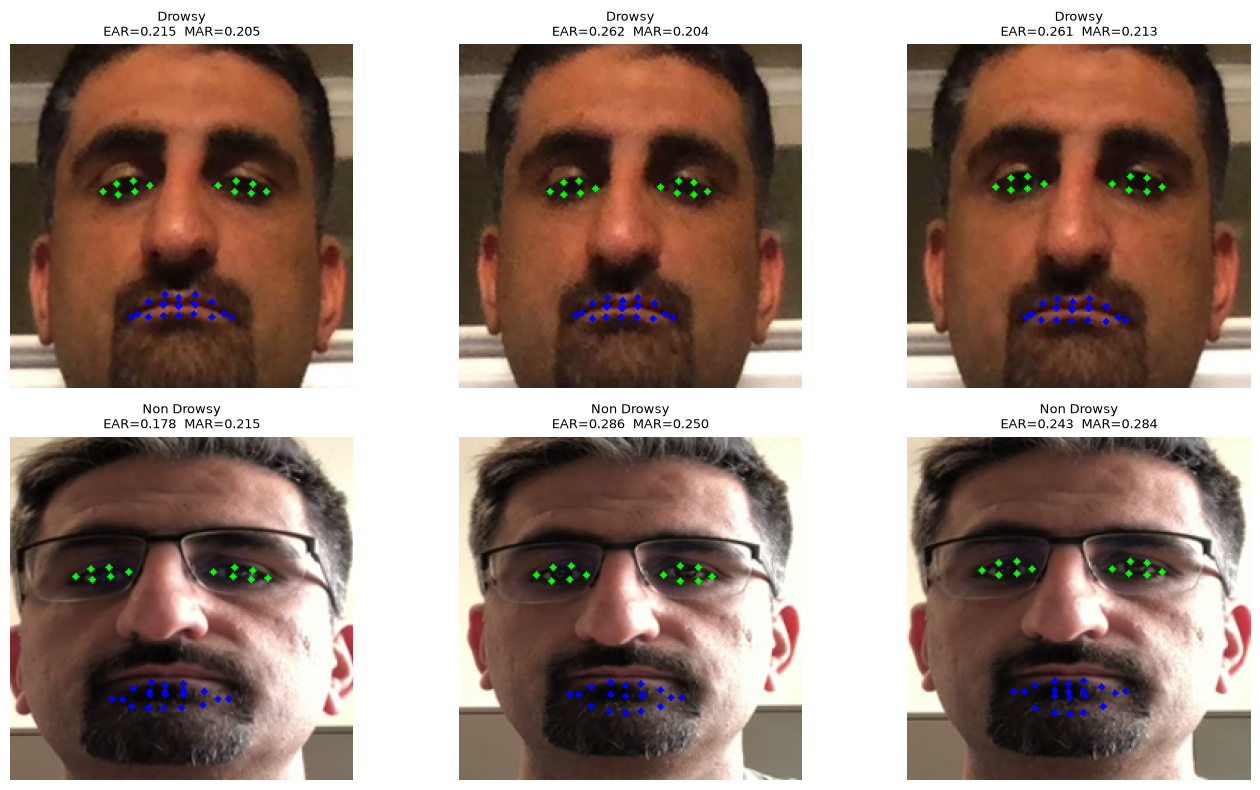

In [26]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, (fname, cls) in zip(axes.flatten(), samples):
    path = f'{old_data}/{cls}/{fname}'
    img  = cv2.imread(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = detector(gray, 1)
    if faces:
        lm = predictor(gray, faces[0])
        for i in range(36, 48): cv2.circle(img, (lm.part(i).x, lm.part(i).y), 2, (0,255,0), -1)
        for i in range(48, 68): cv2.circle(img, (lm.part(i).x, lm.part(i).y), 2, (255,0,0), -1)
        f = extract_features(path)
        ax.set_title(f"{cls}\nEAR={f['ear']:.3f}  MAR={f['mar']:.3f}", fontsize=9)
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.axis('off')
plt.tight_layout()
plt.show()

In [16]:
def get_subject(filename):
    return re.match(r'^([A-Za-z]+)', os.path.basename(filename)).group(1).upper()

rows = []
for cls in classes:
    src_dir = os.path.join(old_data, cls)
    label = 1 if cls == 'Drowsy' else 0
    files = sorted(f for f in os.listdir(src_dir) if f.lower().endswith('.png'))
    for i, f in enumerate(files):
        feats = extract_features(os.path.join(src_dir, f))
        if feats:
            rows.append({'subject': get_subject(f), 'label': label, **feats})
        if i % 1000 == 0:
            print(f"{cls}: {i}/{len(files)}")

Drowsy: 0/22348
Drowsy: 1000/22348
Drowsy: 2000/22348
Drowsy: 3000/22348
Drowsy: 4000/22348
Drowsy: 5000/22348
Drowsy: 6000/22348
Drowsy: 7000/22348
Drowsy: 8000/22348
Drowsy: 9000/22348
Drowsy: 10000/22348
Drowsy: 11000/22348
Drowsy: 12000/22348
Drowsy: 13000/22348
Drowsy: 14000/22348
Drowsy: 15000/22348
Drowsy: 16000/22348
Drowsy: 17000/22348
Drowsy: 18000/22348
Drowsy: 19000/22348
Drowsy: 20000/22348
Drowsy: 21000/22348
Drowsy: 22000/22348
Non Drowsy: 0/19445
Non Drowsy: 1000/19445
Non Drowsy: 2000/19445
Non Drowsy: 3000/19445
Non Drowsy: 4000/19445
Non Drowsy: 5000/19445
Non Drowsy: 6000/19445
Non Drowsy: 7000/19445
Non Drowsy: 8000/19445
Non Drowsy: 9000/19445
Non Drowsy: 10000/19445
Non Drowsy: 11000/19445
Non Drowsy: 12000/19445
Non Drowsy: 13000/19445
Non Drowsy: 14000/19445
Non Drowsy: 15000/19445
Non Drowsy: 16000/19445
Non Drowsy: 17000/19445
Non Drowsy: 18000/19445
Non Drowsy: 19000/19445


In [18]:
df = pd.DataFrame(rows)
print(f"{len(df)} samples — {df.label.sum()} drowsy, {(df.label==0).sum()} non-drowsy, {len(df[df.label.isna()])} dropped (no face detected)")
df.head()

39123 samples — 20637 drowsy, 18486 non-drowsy, 0 dropped (no face detected)


,subject,label,ear,mar
0,A,1,0.215082,0.205107
1,A,1,0.262488,0.203700
2,A,1,0.261289,0.212564
3,A,1,0.282214,0.203326
4,A,1,0.341315,0.187825


In [19]:
df.to_csv('../data/landmarks.csv', index=False)
print('Saved.')

Saved.


In [20]:
rng = np.random.default_rng(42)
subjects = sorted(df['subject'].unique())
rng.shuffle(subjects)

n = len(subjects)
n_val, n_test = max(1, round(n * 0.15)), max(1, round(n * 0.15))

split_map = {s: 'val'   for s in subjects[:n_val]}
split_map.update({s: 'test'  for s in subjects[n_val:n_val+n_test]})
split_map.update({s: 'train' for s in subjects[n_val+n_test:]})

df['split'] = df['subject'].map(split_map)
for sp in ('train', 'val', 'test'):
    sub = df[df.split == sp]
    print(f"{sp}: {len(sub)} samples, {sub.subject.nunique()} subjects")

train: 26059 samples, 20 subjects
val: 6702 samples, 4 subjects
test: 6362 samples, 4 subjects


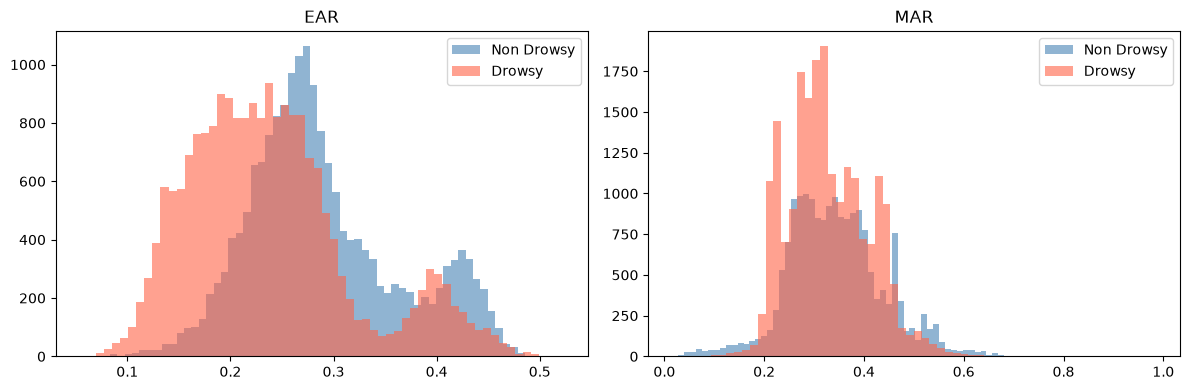

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, feat in zip(axes, ['ear', 'mar']):
    for label, color, name in [(0,'steelblue','Non Drowsy'), (1,'tomato','Drowsy')]:
        ax.hist(df[df.label==label][feat], bins=60, alpha=0.6, color=color, label=name)
    ax.set_title(feat.upper())
    ax.legend()
plt.tight_layout()
plt.show()

In [40]:
WINDOW = 50
STEP   = 10

window_rows = []
for (subject, label), group in df.groupby(['subject', 'label']):
    frames = group[['ear', 'mar']].values
    for start in range(0, len(frames) - WINDOW + 1, STEP):
        w = frames[start:start+WINDOW]
        window_rows.append({
            'subject':  subject,
            'label':    label,
            'mean_ear': w[:,0].mean(),
            'min_ear':  w[:,0].min(),
            'std_ear':  w[:,0].std(),
            'mean_mar': w[:,1].mean(),
        })

wdf = pd.DataFrame(window_rows)
print(f"{len(wdf)} windows — {int(wdf.label.sum())} drowsy, {(wdf.label==0).sum()} non-drowsy")

3671 windows — 1939 drowsy, 1732 non-drowsy


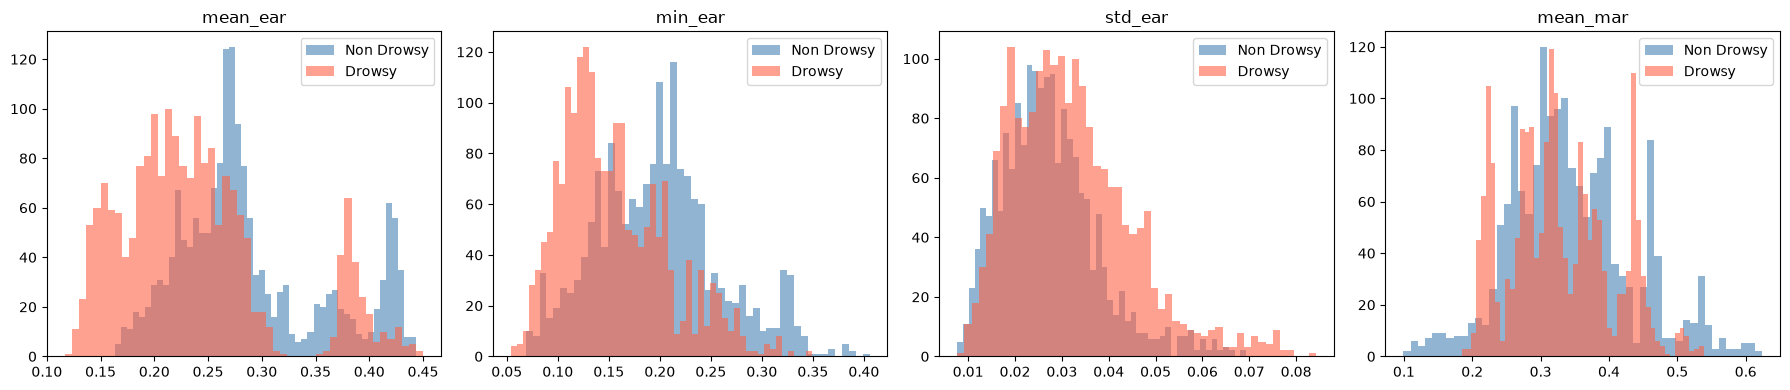

In [41]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, feat in zip(axes, ['mean_ear', 'min_ear', 'std_ear', 'mean_mar']):
    for label, color, name in [(0,'steelblue','Non Drowsy'), (1,'tomato','Drowsy')]:
        ax.hist(wdf[wdf.label==label][feat], bins=50, alpha=0.6, color=color, label=name)
    ax.set_title(feat)
    ax.legend()
plt.tight_layout()
plt.show()

In [42]:
wdf['split'] = wdf['subject'].map(split_map)

feats = ['mean_ear', 'min_ear', 'std_ear', 'mean_mar']
train = wdf[wdf.split == 'train']
val   = wdf[wdf.split == 'val']
test  = wdf[wdf.split == 'test']

X_train, y_train = train[feats].values, train['label'].values
X_val,   y_val   = val[feats].values,   val['label'].values
X_test,  y_test  = test[feats].values,  test['label'].values

In [43]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report

clf = GradientBoostingClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

print("Val:")
print(classification_report(y_val, clf.predict(X_val), target_names=['Non Drowsy', 'Drowsy']))
print("Test:")
print(classification_report(y_test, clf.predict(X_test), target_names=['Non Drowsy', 'Drowsy']))

Val:
              precision    recall  f1-score   support

  Non Drowsy       0.47      0.55      0.51       255
      Drowsy       0.66      0.59      0.62       380

    accuracy                           0.57       635
   macro avg       0.57      0.57      0.57       635
weighted avg       0.59      0.57      0.58       635

Test:
              precision    recall  f1-score   support

  Non Drowsy       0.51      0.44      0.47       317
      Drowsy       0.47      0.54      0.50       287

    accuracy                           0.49       604
   macro avg       0.49      0.49      0.49       604
weighted avg       0.49      0.49      0.49       604



In [ ]:
EAR_THRESHOLD = 0.75  # alert if EAR drops below 75% of personal baseline
CONSEC_FRAMES = 30    # consecutive frames below threshold before alert

def calibrate(ear_series):
    return np.mean(ear_series)

def detect(ear_series, baseline):
    consec, alerts = 0, []
    for e in ear_series:
        consec = consec + 1 if e < baseline * EAR_THRESHOLD else 0
        alerts.append(consec >= CONSEC_FRAMES)
    return np.array(alerts)